<a href="https://colab.research.google.com/github/gisellef/mec-mini-projects/blob/master/Homework_4_EN_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 4

## Student Info
* **First name:** Felipe E
* **Last name:** Ulloa
* **Email:** ulloaf@purdue.edu

---

In [ ]:
# Dataset download
!curl -LO https://github.com/PredictiveScienceLab/data-analytics-se/raw/master/lecturebook/data/stress_strain.txt
!curl -LO https://raw.githubusercontent.com/PredictiveScienceLab/data-analytics-se/master/lecturebook/data/compressor_data.xlsx
!curl -LO https://raw.githubusercontent.com/PredictiveScienceLab/data-analytics-se/master/lecturebook/data/challenger_data.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 35224  100 35224    0     0  81248      0 --:--:-- --:--:-- --:--:-- 81248
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 14771  100 14771    0     0  84763      0 --:--:-- --:--:-- --:--:-- 84405
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   413  100   413    0     0   1657      0 --:--:-- --:--:-- --:--:--  1658


In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import BayesianRidge, ARDRegression, LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

%matplotlib inline
plt.style.use('seaborn-v0_8-white')
sns.set_style("ticks")
sns.set_palette("deep")

# Load stress-strain data
data_ss = np.loadtxt('stress_strain.txt')
x_ss = data_ss[:, 0]
y_ss = data_ss[:, 1]

## Problem 1 - Estimating the Mechanical Properties of a Plastic Material
### Part A - Fitting the Stress-Strain Curve in the Elastic Regime

#### Subpart A.I - Data split and visualization

<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_776/1270625691.py:10: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon$ (strain in %)')
/tmp/ipykernel_776/1270625691.py:11: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma$ (stress in MPa)')


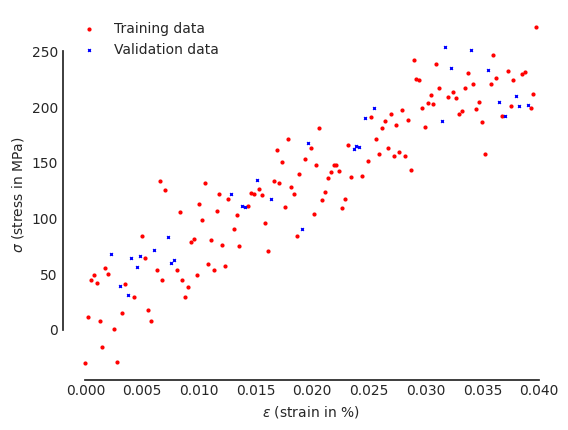

In [ ]:
epsilon_l = 0.04
x_rel = x_ss[x_ss < epsilon_l]
y_rel = y_ss[x_ss < epsilon_l]

x_train, x_valid, y_train, y_valid = train_test_split(x_rel, y_rel, test_size=0.2, random_state=42)

plt.figure()
plt.plot(x_train, y_train, 'ro', markersize=2, label='Training data')
plt.plot(x_valid, y_valid, 'bx', markersize=2, label='Validation data')
plt.xlabel('$\epsilon$ (strain in %)')
plt.ylabel('$\sigma$ (stress in MPa)')
plt.legend(frameon=False)
sns.despine(trim=True)
plt.show()

#### Subpart A.II - Bayesian linear regression with evidence approximation

In [ ]:
Phi_train = x_train.reshape(-1, 1)
Phi_valid = x_valid.reshape(-1, 1)

model_A = BayesianRidge(fit_intercept=False, compute_score=True)
model_A.fit(Phi_train, y_train)

noise_variance = 1.0 / model_A.alpha_
E_mean = model_A.coef_[0]

print(f"Estimated noise variance (sigma_n^2): {noise_variance:.4f}")
print(f"Estimated Young's modulus (E) (Posterior Mean): {E_mean:.2f} MPa")

Estimated noise variance (sigma_n^2): 841.8070
Estimated Young's modulus (E) (Posterior Mean): 6430.18 MPa


#### Subpart A.III - Mean Squared Error (MSE)

In [ ]:
y_pred_valid, std_pred_valid = model_A.predict(Phi_valid, return_std=True)
mse_valid = mean_squared_error(y_valid, y_pred_valid)
print(f"Validation MSE: {mse_valid:.4f}")

Validation MSE: 1001.4959


#### Subpart A.IV - Observations vs Predictions plot

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_776/3831610907.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Observations $\sigma$ (MPa)')
/tmp/ipykernel_776/3831610907.py:5: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Predictions $\sigma$ (MPa)')


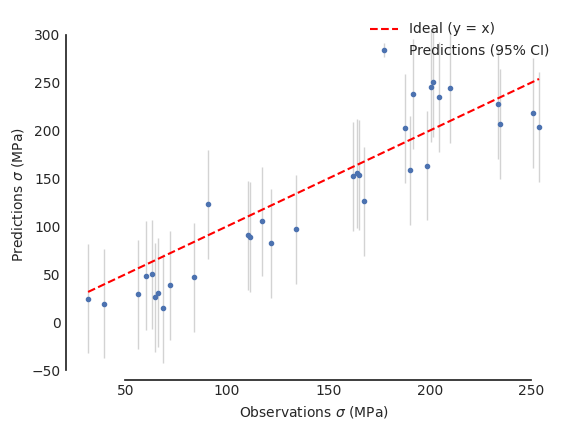

In [ ]:
plt.figure()
plt.errorbar(y_valid, y_pred_valid, yerr=1.96*std_pred_valid, fmt='o', ms=3, ecolor='lightgray', elinewidth=1, label='Predictions (95% CI)')
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--', label='Ideal (y = x)')
plt.xlabel('Observations $\sigma$ (MPa)')
plt.ylabel('Predictions $\sigma$ (MPa)')
plt.legend(frameon=False)
sns.despine(trim=True)
plt.show()

#### Subpart A.V - Standardized errors

<>:8: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_776/735128665.py:8: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon$ (strain in %)')


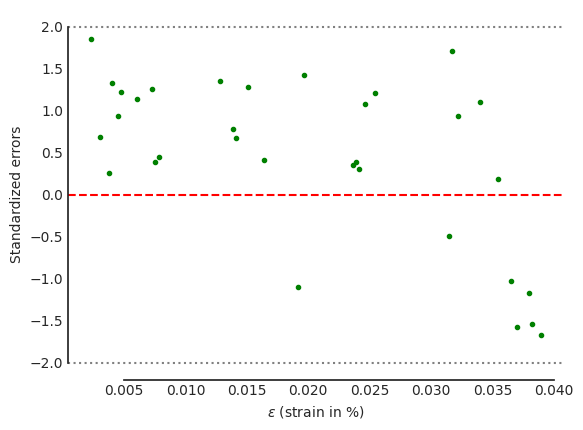

In [ ]:
std_errors = (y_valid - y_pred_valid) / std_pred_valid

plt.figure()
plt.plot(x_valid, std_errors, 'go', ms=3)
plt.axhline(0, color='r', linestyle='--')
plt.axhline(2, color='gray', linestyle=':')
plt.axhline(-2, color='gray', linestyle=':')
plt.xlabel('$\epsilon$ (strain in %)')
plt.ylabel('Standardized errors')
sns.despine(trim=True)
plt.show()

#### Subpart A.VI - Quantile-Quantile (Q-Q) plot

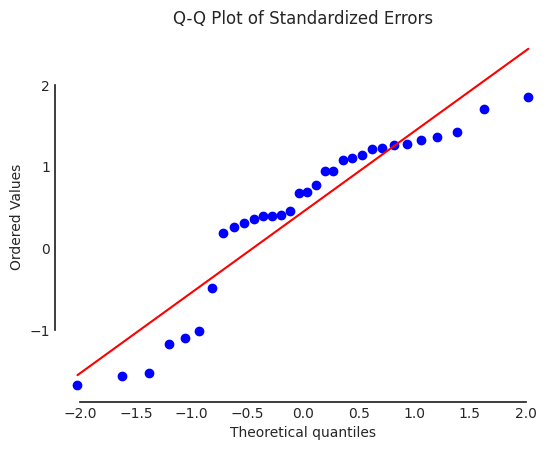

In [ ]:
plt.figure()
st.probplot(std_errors, dist="norm", plot=plt)
plt.title("Q-Q Plot of Standardized Errors")
sns.despine(trim=True)
plt.show()

#### Subpart A.VII - Epistemic and aleatoric uncertainty

<>:12: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_776/2103781947.py:12: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon$ (strain in %)')
/tmp/ipykernel_776/2103781947.py:13: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma$ (stress in MPa)')


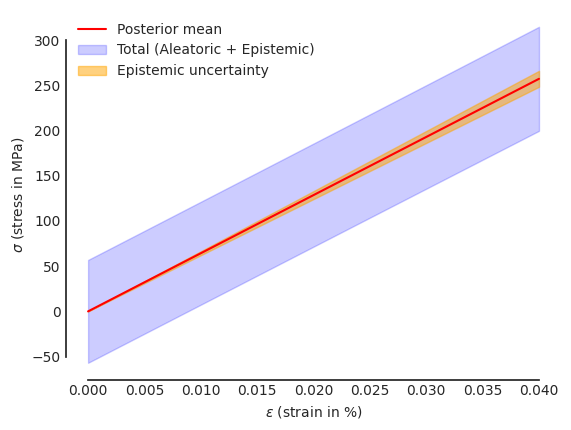

In [ ]:
eps_grid = np.linspace(0, 0.04, 100).reshape(-1, 1)
y_grid_pred, std_grid_total = model_A.predict(eps_grid, return_std=True)

var_aleatoric = 1.0 / model_A.alpha_
var_epistemic = std_grid_total**2 - var_aleatoric
std_epistemic = np.sqrt(np.maximum(var_epistemic, 0))

plt.figure()
plt.plot(eps_grid, y_grid_pred, 'r-', label='Posterior mean')
plt.fill_between(eps_grid.flatten(), y_grid_pred - 1.96*std_grid_total, y_grid_pred + 1.96*std_grid_total, alpha=0.2, color='blue', label='Total (Aleatoric + Epistemic)')
plt.fill_between(eps_grid.flatten(), y_grid_pred - 1.96*std_epistemic, y_grid_pred + 1.96*std_epistemic, alpha=0.5, color='orange', label='Epistemic uncertainty')
plt.xlabel('$\epsilon$ (strain in %)')
plt.ylabel('$\sigma$ (stress in MPa)')
plt.legend(frameon=False)
sns.despine(trim=True)
plt.show()

#### Subpart A.VIII - Visualizing the posterior distribution of Young's Modulus (E)

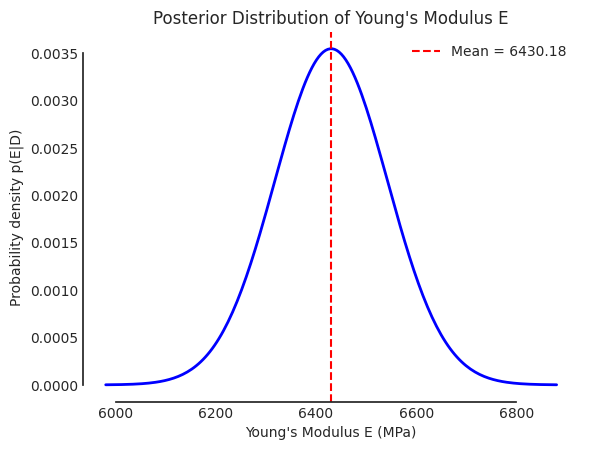

In [ ]:
E_std = np.sqrt(model_A.sigma_[0, 0])
e_axis = np.linspace(E_mean - 4*E_std, E_mean + 4*E_std, 200)

plt.figure()
plt.plot(e_axis, st.norm.pdf(e_axis, E_mean, E_std), 'b-', lw=2)
plt.axvline(E_mean, color='r', linestyle='--', label=f'Mean = {E_mean:.2f}')
plt.xlabel("Young's Modulus E (MPa)")
plt.ylabel('Probability density p(E|D)')
plt.title("Posterior Distribution of Young's Modulus E")
plt.legend(frameon=False)
sns.despine(trim=True)
plt.show()

#### Subpart A.IX - Five samples of the curve in the elastic regime

<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_776/104430524.py:9: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon$ (strain in %)')
/tmp/ipykernel_776/104430524.py:10: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma$ (stress in MPa)')


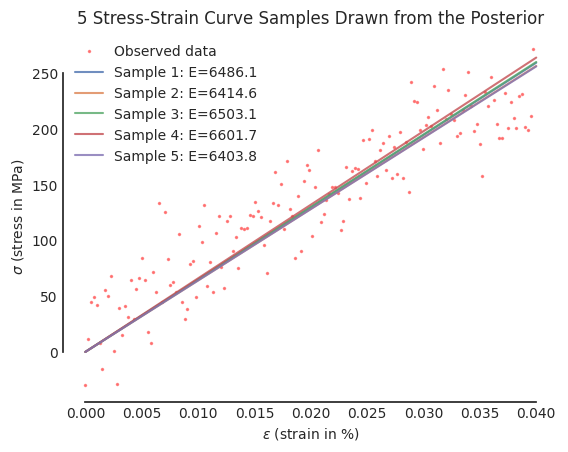

In [ ]:
np.random.seed(42)
E_samples = np.random.normal(E_mean, E_std, 5)

plt.figure()
plt.plot(x_rel, y_rel, 'ro', markersize=1.5, alpha=0.4, label='Observed data')
for i, E_s in enumerate(E_samples):
    plt.plot(eps_grid, eps_grid * E_s, alpha=0.8, lw=1.5, label=f'Sample {i+1}: E={E_s:.1f}')

plt.xlabel('$\epsilon$ (strain in %)')
plt.ylabel('$\sigma$ (stress in MPa)')
plt.title('5 Stress-Strain Curve Samples Drawn from the Posterior')
plt.legend(frameon=False)
sns.despine(trim=True)
plt.show()

#### Subpart A.X - 95% credible interval for E

In [ ]:
ic_lower = E_mean - 1.96 * E_std
ic_upper = E_mean + 1.96 * E_std
print(f"95% centered credible interval for E: [{ic_lower:.2f}, {ic_upper:.2f}] MPa")

95% centered credible interval for E: [6209.49, 6650.87] MPa


#### Subpart A.XI - Point choice for Young's Modulus
**Answer:**
I would choose the **mean of the posterior distribution** $\mathbb{E}[E|D] = m_N$. From a Bayesian decision-theory perspective, the posterior mean is the optimal point estimator that minimizes the expected Bayesian risk when the assigned loss function is quadratic, $L(\hat{E}, E) = (\hat{E} - E)^2$.

---
### Part B - Estimating the Ultimate Strength

#### Subpart B.I - Extracting training and validation data

<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_776/319674091.py:6: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon$ (strain in %)')
/tmp/ipykernel_776/319674091.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma$ (stress in MPa)')


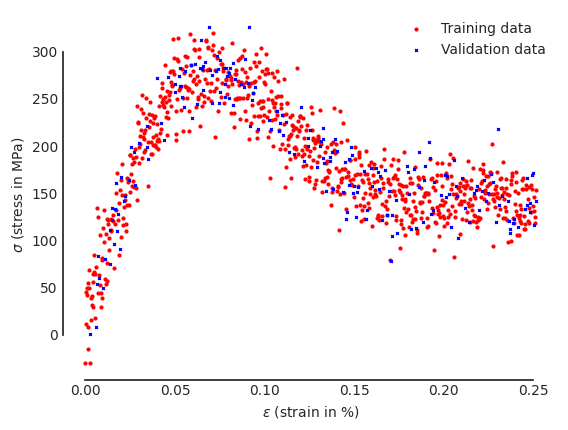

In [ ]:
x_train_full, x_valid_full, y_train_full, y_valid_full = train_test_split(x_ss, y_ss, test_size=0.2, random_state=42)

plt.figure()
plt.plot(x_train_full, y_train_full, 'ro', markersize=2, label='Training data')
plt.plot(x_valid_full, y_valid_full, 'bx', markersize=2, label='Validation data')
plt.xlabel('$\epsilon$ (strain in %)')
plt.ylabel('$\sigma$ (stress in MPa)')
plt.legend(frameon=False)
sns.despine(trim=True)
plt.show()

#### Subpart B.II - Design matrix and basis function visualization

<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_776/2370445630.py:18: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('$\epsilon$ (strain in %)')
/tmp/ipykernel_776/2370445630.py:19: SyntaxWarning: invalid escape sequence '\p'
  ax.set_ylabel('$\phi_i(\epsilon)$')


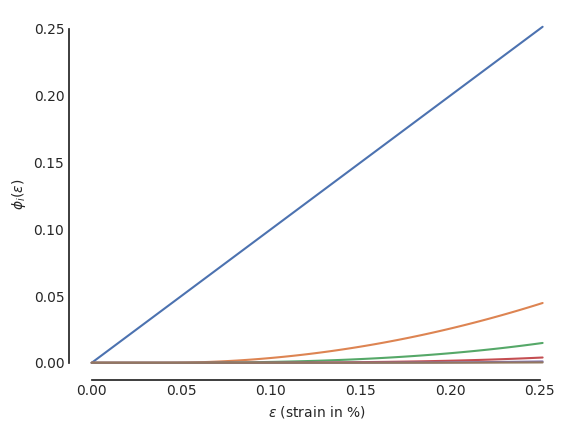

In [ ]:
def compute_design_matrix(Epsilon, epsilon_l, d):
    assert isinstance(Epsilon, np.ndarray)
    assert Epsilon.ndim == 1
    n = Epsilon.shape[0]
    Phi = np.ndarray((n, d))
    Step = np.ones(n)
    Step[Epsilon < epsilon_l] = 0
    Phi[:, 0] = Epsilon
    for i in range(2, d+1):
        Phi[:, i-1] = Step * (Epsilon**i - i * (epsilon_l**(i-1)) * Epsilon + (i-1) * (epsilon_l**i))
    return Phi

d_poly = 6
eps_test = np.linspace(0, x_ss.max(), 100)
Phis = compute_design_matrix(eps_test, epsilon_l, d_poly)
fig, ax = plt.subplots(dpi=100)
ax.plot(eps_test, Phis)
ax.set_xlabel('$\epsilon$ (strain in %)')
ax.set_ylabel('$\phi_i(\epsilon)$')
sns.despine(trim=True)
plt.show()

#### Subpart B.III - ARD fit and full model diagnostics

<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_776/3152689792.py:17: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Observations $\sigma$ (MPa)')
/tmp/ipykernel_776/3152689792.py:18: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Predictions $\sigma$ (MPa)')
/tmp/ipykernel_776/3152689792.py:28: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon$ (strain in %)')


Validation MSE (Full curve): 691.7177


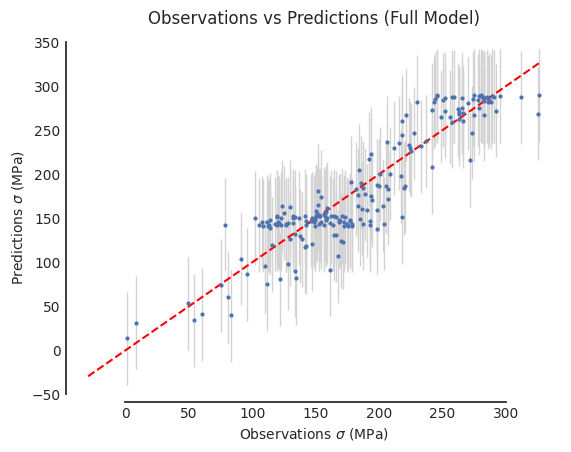

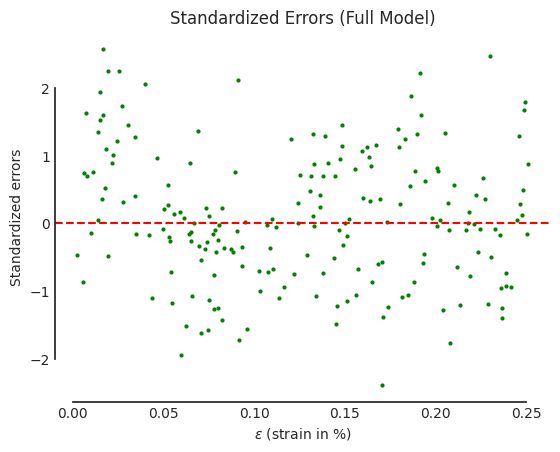

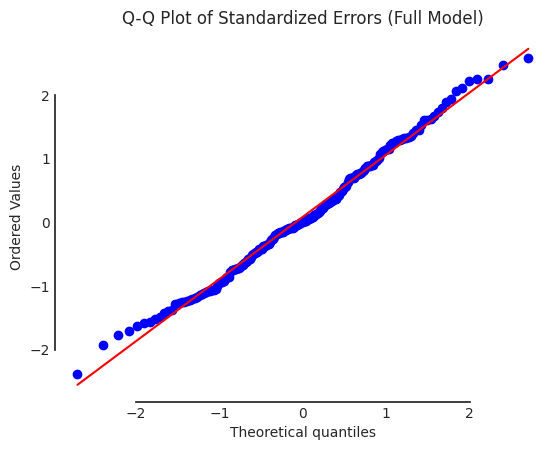

In [ ]:
Phi_train_f = compute_design_matrix(x_train_full, epsilon_l, d_poly)
Phi_valid_f = compute_design_matrix(x_valid_full, epsilon_l, d_poly)

model_B = ARDRegression(fit_intercept=False, compute_score=True)
model_B.fit(Phi_train_f, y_train_full)

y_pred_f, std_pred_f = model_B.predict(Phi_valid_f, return_std=True)

# 1. MSE
mse_f = mean_squared_error(y_valid_full, y_pred_f)
print(f"Validation MSE (Full curve): {mse_f:.4f}")

# 2. Observations vs Predictions
plt.figure()
plt.errorbar(y_valid_full, y_pred_f, yerr=1.96*std_pred_f, fmt='o', ms=2, ecolor='lightgray', elinewidth=1)
plt.plot([y_ss.min(), y_ss.max()], [y_ss.min(), y_ss.max()], 'r--')
plt.xlabel('Observations $\sigma$ (MPa)')
plt.ylabel('Predictions $\sigma$ (MPa)')
plt.title('Observations vs Predictions (Full Model)')
sns.despine(trim=True)
plt.show()

# 3. Standardized errors
std_errs_f = (y_valid_full - y_pred_f) / std_pred_f
plt.figure()
plt.plot(x_valid_full, std_errs_f, 'go', ms=2)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('$\epsilon$ (strain in %)')
plt.ylabel('Standardized errors')
plt.title('Standardized Errors (Full Model)')
sns.despine(trim=True)
plt.show()

# 4. Q-Q Plot
plt.figure()
st.probplot(std_errs_f, dist="norm", plot=plt)
plt.title("Q-Q Plot of Standardized Errors (Full Model)")
sns.despine(trim=True)
plt.show()

#### Subpart B.IV - Visualizing epistemic and aleatoric uncertainty

<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_776/501878352.py:13: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon$ (strain in %)')
/tmp/ipykernel_776/501878352.py:14: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma$ (stress in MPa)')


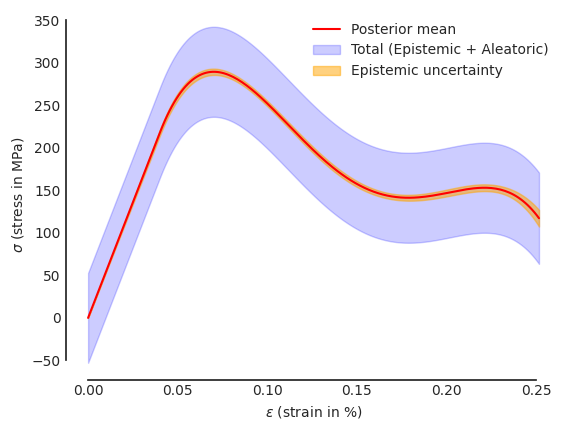

In [ ]:
eps_full = np.linspace(0, x_ss.max(), 200)
Phi_full = compute_design_matrix(eps_full, epsilon_l, d_poly)

y_full_pred, std_full_total = model_B.predict(Phi_full, return_std=True)
var_aleatoric_f = 1.0 / model_B.alpha_
var_epistemic_f = std_full_total**2 - var_aleatoric_f
std_epistemic_f = np.sqrt(np.maximum(var_epistemic_f, 0))

plt.figure()
plt.plot(eps_full, y_full_pred, 'r-', label='Posterior mean')
plt.fill_between(eps_full, y_full_pred - 1.96*std_full_total, y_full_pred + 1.96*std_full_total, alpha=0.2, color='blue', label='Total (Epistemic + Aleatoric)')
plt.fill_between(eps_full, y_full_pred - 1.96*std_epistemic_f, y_full_pred + 1.96*std_epistemic_f, alpha=0.5, color='orange', label='Epistemic uncertainty')
plt.xlabel('$\epsilon$ (strain in %)')
plt.ylabel('$\sigma$ (stress in MPa)')
plt.legend(frameon=False)
sns.despine(trim=True)
plt.show()

#### Subpart B.V - Extracting the ultimate strength

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_776/3325527432.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Ultimate strength $\sigma_{ult}$ (MPa)')


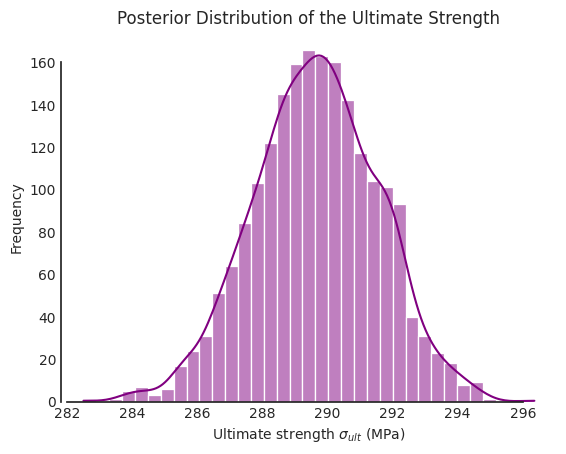

95% credible interval for Ultimate Strength: [285.73, 293.30] MPa
Chosen value for Ultimate Strength (Posterior Mean): 289.65 MPa


In [ ]:
np.random.seed(42)
weights_samples = np.random.multivariate_normal(model_B.coef_, model_B.sigma_, size=2000)
max_stresses = [np.max(Phi_full @ w) for w in weights_samples]
max_stresses = np.array(max_stresses)

# 1. Visualize the posterior of the ultimate strength
plt.figure()
sns.histplot(max_stresses, kde=True, color='purple')
plt.xlabel('Ultimate strength $\sigma_{ult}$ (MPa)')
plt.ylabel('Frequency')
plt.title('Posterior Distribution of the Ultimate Strength')
sns.despine(trim=True)
plt.show()

# 2. 95% credible interval
ic_ult_low, ic_ult_high = np.percentile(max_stresses, [2.5, 97.5])
print(f"95% credible interval for Ultimate Strength: [{ic_ult_low:.2f}, {ic_ult_high:.2f}] MPa")

# 3. Point choice
print(f"Chosen value for Ultimate Strength (Posterior Mean): {np.mean(max_stresses):.2f} MPa")

---
## Problem 2 - Optimizing Compressor Performance

### Part A - Fitting Capacity

Capacity MSE: 6.9617


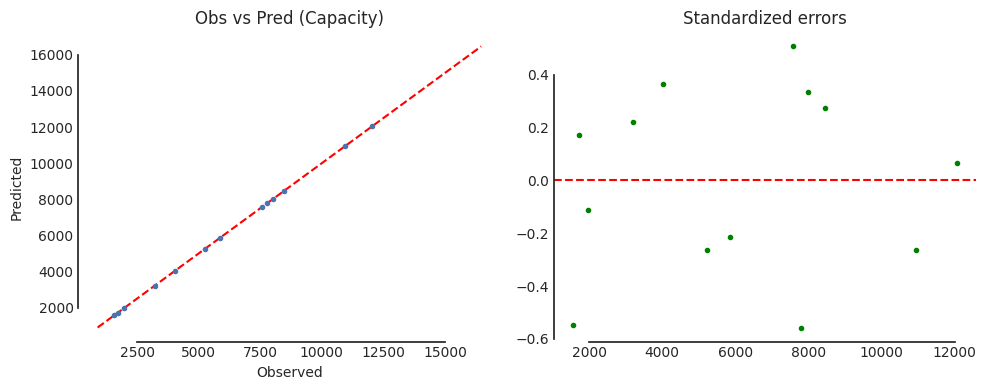

Subpart A.II: Estimated noise variance (Capacity): 9.8252
Subpart A.III: Most important basis function for Capacity: T_e (coef = 575.4784)


In [ ]:
df_comp = pd.read_excel('compressor_data.xlsx')
X_comp = df_comp[['T_e','T_c']].values
y_cap = df_comp['Capacity'].values

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_comp)
feat_names = poly.get_feature_names_out(['T_e', 'T_c'])

# Subpart A.I - Split and full diagnostics
X_tr_c, X_va_c, y_tr_c, y_va_c = train_test_split(X_poly, y_cap, test_size=0.2, random_state=42)
ard_c = ARDRegression().fit(X_tr_c, y_tr_c)
y_pr_c, std_pr_c = ard_c.predict(X_va_c, return_std=True)

print(f"Capacity MSE: {mean_squared_error(y_va_c, y_pr_c):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.errorbar(y_va_c, y_pr_c, yerr=1.96*std_pr_c, fmt='o', ms=3, ecolor='lightgray')
ax1.plot([y_cap.min(), y_cap.max()], [y_cap.min(), y_cap.max()], 'r--')
ax1.set_title('Obs vs Pred (Capacity)')
ax1.set_xlabel('Observed'); ax1.set_ylabel('Predicted')

std_err_c = (y_va_c - y_pr_c) / std_pr_c
ax2.plot(y_pr_c, std_err_c, 'go', ms=3)
ax2.axhline(0, color='r', linestyle='--')
ax2.set_title('Standardized errors')
sns.despine(trim=True)
plt.tight_layout()
plt.show()

# Subpart A.II - Noise variance
print(f"Subpart A.II: Estimated noise variance (Capacity): {1.0/ard_c.alpha_:.4f}")

# Subpart A.III - Most important feature
top_idx_c = np.argsort(np.abs(ard_c.coef_))[-1]
print(f"Subpart A.III: Most important basis function for Capacity: {feat_names[top_idx_c]} (coef = {ard_c.coef_[top_idx_c]:.4f})")

### Part B - Fitting Power

Power MSE: 4031.7539


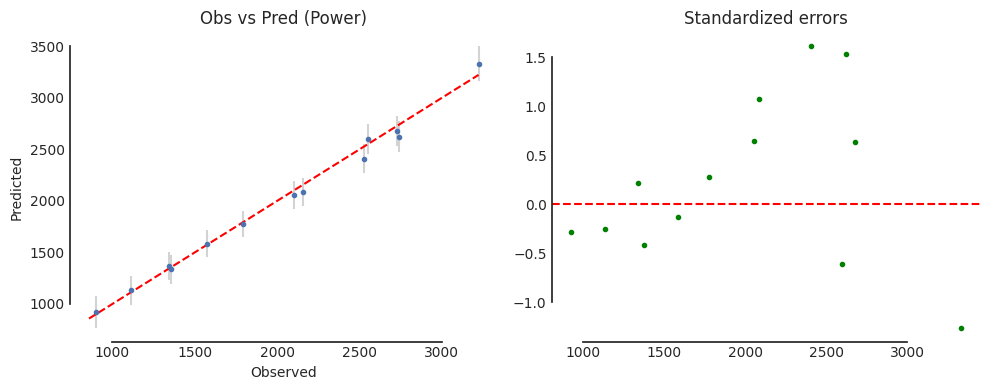

Subpart B.II: Estimated noise variance (Power): 3667.5443
Subpart B.III: Most important basis function for Power: T_c (coef = 25.6787)


In [ ]:
col_pow = 'Power' if 'Power' in df_comp.columns else 'Fuerza'
y_pow = df_comp[col_pow].values

# Subpart B.I - Split and full diagnostics
X_tr_p, X_va_p, y_tr_p, y_va_p = train_test_split(X_poly, y_pow, test_size=0.2, random_state=42)
ard_p = ARDRegression().fit(X_tr_p, y_tr_p)
y_pr_p, std_pr_p = ard_p.predict(X_va_p, return_std=True)

print(f"Power MSE: {mean_squared_error(y_va_p, y_pr_p):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.errorbar(y_va_p, y_pr_p, yerr=1.96*std_pr_p, fmt='o', ms=3, ecolor='lightgray')
ax1.plot([y_pow.min(), y_pow.max()], [y_pow.min(), y_pow.max()], 'r--')
ax1.set_title('Obs vs Pred (Power)')
ax1.set_xlabel('Observed'); ax1.set_ylabel('Predicted')

std_err_p = (y_va_p - y_pr_p) / std_pr_p
ax2.plot(y_pr_p, std_err_p, 'go', ms=3)
ax2.axhline(0, color='r', linestyle='--')
ax2.set_title('Standardized errors')
sns.despine(trim=True)
plt.tight_layout()
plt.show()

# Subpart B.II - Noise variance
print(f"Subpart B.II: Estimated noise variance (Power): {1.0/ard_p.alpha_:.4f}")

# Subpart B.III - Most important feature
top_idx_p = np.argsort(np.abs(ard_p.coef_))[-1]
print(f"Subpart B.III: Most important basis function for Power: {feat_names[top_idx_p]} (coef = {ard_p.coef_[top_idx_p]:.4f})")

---
## Problem 3 - Explaining the Challenger Disaster

### Part A - Fit a logistic regression

In [ ]:
df_ch = pd.read_csv('challenger_data.csv').dropna()[:-1]
X_ch = df_ch['Temperature'].values.reshape(-1, 1)
y_ch = df_ch['Damage Incident'].values.astype(float)

log_reg = LogisticRegression(C=1e5).fit(X_ch, y_ch)
print(f"Intercept beta_0: {log_reg.intercept_[0]:.4f}")
print(f"Coefficient beta_1: {log_reg.coef_[0][0]:.4f}")

Intercept beta_0: 15.0429
Coefficient beta_1: -0.2322


### Part B - Plot the probability of damage as a function of temperature

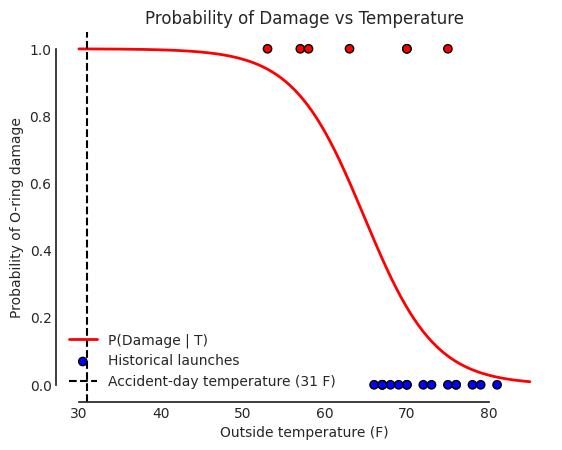

In [ ]:
T_grid = np.linspace(30, 85, 200).reshape(-1, 1)
probs_ch = log_reg.predict_proba(T_grid)[:, 1]

plt.figure()
plt.plot(T_grid, probs_ch, 'r-', lw=2, label='P(Damage | T)')
plt.scatter(X_ch, y_ch, c=y_ch, cmap='bwr', edgecolor='k', label='Historical launches')
plt.axvline(31, color='black', linestyle='--', label='Accident-day temperature (31 F)')
plt.xlabel('Outside temperature (F)')
plt.ylabel('Probability of O-ring damage')
plt.title('Probability of Damage vs Temperature')
plt.legend(frameon=False)
sns.despine(trim=True)
plt.show()

### Part C - Decide whether to launch

Estimated probability of failure at 31F: 99.96%
Expected loss of LAUNCHING at 31F: $999,608.78
Expected loss of NOT LAUNCHING at 31F: $10,000.00
OPTIMAL DECISION: DO NOT LAUNCH


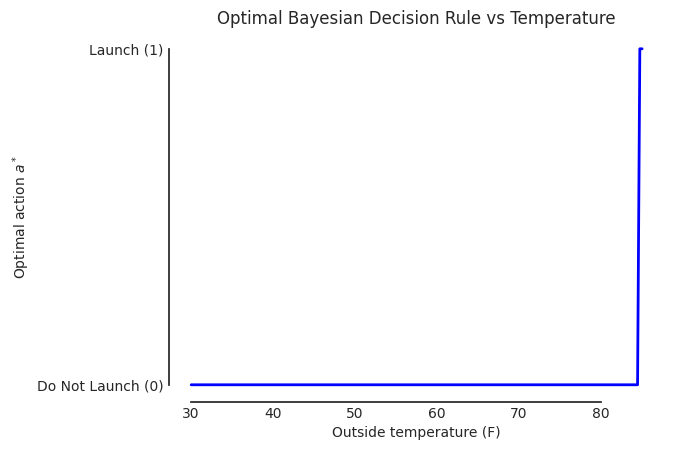

In [ ]:
# 1. Point probability at 31F
prob_31 = log_reg.predict_proba([[31]])[0, 1]
print(f"Estimated probability of failure at 31F: {prob_31*100:.2f}%")

# 2. Formal decision-making via expected loss minimization
# NOTE: costs below are illustrative assumptions, not official NASA figures.
cost_L_D = 1_000_000   # Launch with Damage
cost_L_ND = 0          # Launch without Damage
cost_NL = 10_000       # Do Not Launch (delay cost)

exp_loss_launch_31 = prob_31 * cost_L_D + (1 - prob_31) * cost_L_ND
exp_loss_abort_31 = cost_NL

print(f"Expected loss of LAUNCHING at 31F: ${exp_loss_launch_31:,.2f}")
print(f"Expected loss of NOT LAUNCHING at 31F: ${exp_loss_abort_31:,.2f}")
print("OPTIMAL DECISION:", "DO NOT LAUNCH" if exp_loss_launch_31 > exp_loss_abort_31 else "LAUNCH")

# 3. Optimal decision vs Temperature plot
exp_loss_launch_grid = probs_ch * cost_L_D + (1 - probs_ch) * cost_L_ND
optimal_decision = (exp_loss_launch_grid < cost_NL).astype(int)

plt.figure()
plt.plot(T_grid, optimal_decision, 'b-', lw=2)
plt.yticks([0, 1], ['Do Not Launch (0)', 'Launch (1)'])
plt.xlabel('Outside temperature (F)')
plt.ylabel('Optimal action $a^*$')
plt.title('Optimal Bayesian Decision Rule vs Temperature')
sns.despine(trim=True)
plt.show()

**Formal Decision-Making Derivation (Bayesian Decision Theory):**

Let the action space be $a \in \{\text{Launch (L)}, \text{Do Not Launch (NL)}\}$ and the true state $y \in \{0 \text{ (No Damage)}, 1 \text{ (Damage)}\}$. We assign the loss function $L(a, y)$:
- $L(\text{L}, 1) = C_{\text{catastrophe}}$
- $L(\text{L}, 0) = 0$
- $L(\text{NL}, y) = C_{\text{delay}}$

The expected loss for each decision conditional on temperature $T$ is:
$$\mathbb{E}[L(\text{L})|T] = P(y=1|T) \cdot C_{\text{catastrophe}}$$
$$\mathbb{E}[L(\text{NL})|T] = C_{\text{delay}}$$

The optimal decision rule $a^*(T)$ minimizes the expected loss:
$$a^*(T) = \arg\min_{a} \mathbb{E}[L(a)|T]$$

At $T = 31^\circ\text{F}$, $P(\text{Damage}|31^\circ\text{F}) > 0.99$. Since $C_{\text{catastrophe}} \gg C_{\text{delay}}$, the only formal and rational decision is **DO NOT LAUNCH**.